# SSS restoring maps and timeseries

See
- https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/44
- https://github.com/ACCESS-NRI/dev_coupling/issues/63#issuecomment-3383664728
- https://github.com/AndyHoggANU/ACCESS-CM2-025-diagnostics/blob/5786ccf/MarginalSeas.ipynb

In [1]:
# These first two cells must be in all notebooks!
# It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in 
# arguments externally using papermill (see mkfigs.sh for details)

# Set esm_file to the datastore for the main experiment of interest
# esm_file = "/g/data/ol01/outputs/access-om3-25km/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json"
# esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json"
esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json"

# papermill settings. *No need to modify these if running interactively.* 
papermill = False                      # `cwd` and `nbname` will be populated by papermill.
cwd = None                             # current working directory 
nbname = None                          # notebook name

In [2]:
if not papermill: 
    import nci_ipynb, os  # requires conda/analysis3-26.03 or later
    cwd = nci_ipynb.dir()
    nbname = nci_ipynb.name()
    os.chdir(cwd)
from mkfigs_configdoc import MkmdWriter
mkmd = MkmdWriter(esm_file, nbname, str(cwd), pm=papermill)

In [3]:
import xarray as xr
import gsw
import intake
from dask.distributed import Client
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import cmocean as cm
import cartopy.crs as ccrs
from shapely import geometry
import calendar
import cftime
import textwrap
import numpy as np
from tqdm.notebook import tqdm

In [4]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
client = Client(threads_per_worker=1)
print(client.dashboard_link)

/proxy/8787/status


2026-06-03 20:52:49,273 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:43765' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('array-2fe5916e3491239d1ac25ba2338dfe46', 5), ('rechunk-merge-3936034959b2067ac4f475aa5342ec2a', 5, 7), ('concatenate-c1d2a3454bc58b90fdce08f56fe1ecb2', 55, 5, 6), ('array-2fe5916e3491239d1ac25ba2338dfe46', 0), ('getitem-3cefc763427b600498a1e7c60361f316', 58, 5, 8)} (stimulus_id='handle-worker-cleanup-1780483969.273726')
2026-06-03 20:52:49,337 - distributed.nanny - WARNING - Restarting worker
2026-06-03 20:53:26,006 - distributed.nanny - WARNING - Restarting worker


In [6]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 14
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42777,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45659,Total threads: 1
Dashboard: /proxy/33023/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:32905,


In [7]:
IAF = esm_file.find('iaf') > 0
IAF

True

In [8]:
om3exptname = os.path.basename(os.path.dirname(esm_file))
om3exptname

'MC_25km_jra_iaf+wombatlite-test3v2-00532b88'

## Load ACCESS-OM3 data from ESM datastore

In [9]:
catalogs = [
                # '/g/data/ol01/access-om3-output/access-om3-025/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json',
                esm_file,
                '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm1-d968c801/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm2-5dc49da6/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm3-da330542/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm4-9fd08880/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm5-9b5dbfa9/datastore.json',
            ]
catalogs

['/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json',
 '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415/datastore.json']

In [10]:
om3datastores = { os.path.normpath(c).split(os.sep)[-2]:
               intake.open_esm_datastore(c,
                                         columns_with_iterables=[
                                            "variable",
                                            "variable_long_name",
                                            "variable_standard_name",
                                            "variable_cell_methods",
                                            "variable_units"]
                                        )
              for c in catalogs }
om3datastores

{'MC_25km_jra_iaf+wombatlite-test3v2-00532b88': <datastore catalog with 24 dataset(s) from 32927 asset(s)>,
 'MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415': <datastore catalog with 24 dataset(s) from 16791 asset(s)>}

In [11]:
om3varnames = [
                "salt_flux_added",
                "sos",
              ]

om3vars = {
    vname: {expt: ds.search(variable=vname).to_dask(
                xarray_open_kwargs = dict(
                    # chunks={"xh": -1, "yh": -1},
                    chunks={"time": -1},
                    decode_timedelta=True,
                    use_cftime=True
                )
            )[vname]
            for expt, ds in om3datastores.items()
          }
    for vname in om3varnames
    }

for vname in om3varnames:
    # define cell-area-weighted versions of all variables
    vname_int = f"{vname}_int"
    om3vars[vname_int] = dict()
    for expt, ds in om3datastores.items():
        cell_area = ds.search(variable='areacello',
                              path=".*output000.*").to_dask(
                                xarray_open_kwargs = dict(
                                    # chunks={"xh": -1, "yh": -1}
                                    chunks={"time": -1}
                                )
                              )['areacello']
        om3vars[vname_int][expt] = om3vars[vname][expt] * cell_area

for expt, d in om3vars["sos"].items():
  # resample monthly to match salt_flux_added and OM2 data
    om3vars["sos"][expt] = d.resample(time='ME').mean('time')
    
# omit latitudes with grid bug in this run https://github.com/ACCESS-NRI/ocean_model_grid_generator/issues/7
for vname, d in om3vars.items():
    try:
        d['25km-iaf-test-for-AK-expt-7df5ef4c'] = d['25km-iaf-test-for-AK-expt-7df5ef4c'].isel(yh=slice(10, None))
    except ValueError:
        d['25km-iaf-test-for-AK-expt-7df5ef4c'] = d['25km-iaf-test-for-AK-expt-7df5ef4c'].isel(yq=slice(10, None))
    except KeyError:
        pass

if IAF:
    for vname, d in om3vars.items():
        for expt in d:
            try:
                d[expt] = d[expt].convert_calendar("proleptic_gregorian", use_cftime=True)
            except KeyError:
                pass

In [12]:
om3vars

{'salt_flux_added': {'MC_25km_jra_iaf+wombatlite-test3v2-00532b88': <xarray.DataArray 'salt_flux_added' (time: 792, yh: 1152, xh: 1440)> Size: 5GB
  dask.array<getitem, shape=(792, 1152, 1440), dtype=float32, chunksize=(12, 192, 160), chunktype=numpy.ndarray>
  Coordinates:
    * time     (time) object 6kB 1958-01-16 12:00:00 ... 2023-12-16 12:00:00
    * yh       (yh) float64 9kB -81.58 -81.52 -81.45 -81.39 ... 89.74 89.84 89.95
    * xh       (xh) float64 12kB -279.9 -279.6 -279.4 -279.1 ... 79.38 79.62 79.88
  Attributes:
      units:          kg m-2 s-1
      long_name:      Salt flux into ocean at surface due to restoring or flux ...
      cell_methods:   area:mean yh:mean xh:mean time: mean
      cell_measures:  area: areacello
      time_avg_info:  average_T1,average_T2,average_DT,
  'MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415': <xarray.DataArray 'salt_flux_added' (time: 408, yh: 1152, xh: 1440)> Size: 3GB
  dask.array<getitem, shape=(408, 1152, 1440), dtype=float32, chun

## Load ACCESS-OM2 data from ACCESS-NRI Catalog

use control - see https://forum.access-hive.org.au/t/access-om2-control-experiments/258#p-747-ryf-7 - but **note that this does not include topography fixes in the latest OM2 and CM2 configs** - see https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/44#issuecomment-3379637468

In [13]:
if IAF:
    om2exptname = '025deg_jra55_iaf_omip2_cycle1'
    frequency = '1mon'
else:
    om2exptname = '025deg_jra55_ryf9091_gadi'
    frequency='1yr' # for 025deg_jra55_ryf9091_gadi

# datastore = intake.cat.access_nri[om2exptname]
om2datastores = {om2exptname: intake.cat.access_nri[om2exptname]}

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/intake/catalog/utils.py:173: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/intake/catalog/utils.py:182: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")


In [14]:
om2varnames = [
                'sfc_salt_flux_restore',
                'surface_salt',  # uses surface values of 'salt' if 'surface_salt' unavailable
              ]

om2varnames = { k: k for k in om2varnames } # name_in_om2vars: varname_in_netcdf

if 'surface_salt' in om2varnames:
    try:
        _ = ds.search(variable='surface_salt', frequency=frequency).to_dask()
    except ValueError:
        om2varnames['surface_salt'] = 'salt'  # fallback to 3d salt if surface salt unavailable

om2vars = {
    vname: {expt: ds.search(variable=vnamein, frequency=frequency).to_dask(
                xarray_open_kwargs = dict(
                    # chunks={"xt_ocean": -1, "yt_ocean": -1},
                    chunks={"time": -1},
                    decode_timedelta=True,
                    use_cftime=True
                )
            )[vnamein]
            for expt, ds in om2datastores.items()
          }
    for vname, vnamein in om2varnames.items()
    }

# take surface value of any 3d fields
for vname, d in om2vars.items():
    for expt in d:
        try:
            d[expt] = d[expt].isel(st_ocean=0)
        except ValueError:
            pass

for vname in om2varnames:
    # define cell-area-weighted versions of all variables
    vname_int = f"{vname}_int"
    om2vars[vname_int] = dict()
    for expt, ds in om2datastores.items():
        cell_area = ds.search(variable='area_t',
                              path=".*output000.*").to_dask(
                                xarray_open_kwargs = dict(
                                    chunks={"xh": -1, "yh": -1})
                              )['area_t']
        om2vars[vname_int][expt] = om2vars[vname][expt] * cell_area

if IAF:
    for vname, d in om2vars.items():
        for expt in d:
            try:
                d[expt] = d[expt].convert_calendar("proleptic_gregorian", use_cftime=True)
            except KeyError:
                pass

In [15]:
om2vars

{'sfc_salt_flux_restore': {'025deg_jra55_iaf_omip2_cycle1': <xarray.DataArray 'sfc_salt_flux_restore' (time: 732, yt_ocean: 1080,
                                             xt_ocean: 1440)> Size: 5GB
  dask.array<getitem, shape=(732, 1080, 1440), dtype=float32, chunksize=(12, 216, 240), chunktype=numpy.ndarray>
  Coordinates:
    * time      (time) object 6kB 1958-01-14 12:00:00 ... 2018-12-14 12:00:00
    * yt_ocean  (yt_ocean) float64 9kB -81.08 -80.97 -80.87 ... 89.74 89.84 89.95
    * xt_ocean  (xt_ocean) float64 12kB -279.9 -279.6 -279.4 ... 79.38 79.62 79.88
  Attributes:
      long_name:      sfc_salt_flux_restore: flux from restoring term
      units:          kg/(m^2*sec)
      valid_range:    [-10000.  10000.]
      cell_methods:   time: mean
      time_avg_info:  average_T1,average_T2,average_DT},
 'surface_salt': {'025deg_jra55_iaf_omip2_cycle1': <xarray.DataArray 'salt' (time: 732, yt_ocean: 1080, xt_ocean: 1440)> Size: 5GB
  dask.array<getitem, shape=(732, 1080, 1440), 

### Trim to a consistent time range

In [16]:
# find largest overlapping time range

# latest start date in data
datastart = np.max([ om3vars['sos'][e].time.values[0] for e in om3datastores.keys() ])
datastart = max(datastart, np.max([ om2vars['surface_salt'][e].time.values[0] for e in om2datastores.keys() ]))

# earliest end date in data
datastop = np.min([ om3vars['sos'][e].time.values[-1] for e in om3datastores.keys() ])
datastop = min(datastop, np.min([ om2vars['surface_salt'][e].time.values[-1] for e in om2datastores.keys() ]))

print ('common data range:', datastart, ' to ', datastop)

datastoplist = list(cftime.to_tuple(datastop))
datastoplist[0] -= 10  # last 10 years
datastart = max(datastart, cftime.datetime(*datastoplist, calendar=datastop.calendar))

# bracket to start/end of year
datestart = cftime.datetime(cftime.to_tuple(datastart)[0],  1, 1, calendar=datastop.calendar)
datestop  = cftime.datetime(cftime.to_tuple(datastop)[0], 12, 31, 23, 59, 59, calendar=datastop.calendar)

timeslice = slice(datestart, datestop)
timeslice

common data range: 1990-01-31 00:00:00  to  2018-12-14 12:00:00


slice(cftime.datetime(2008, 1, 1, 0, 0, 0, 0, calendar='proleptic_gregorian', has_year_zero=True), cftime.datetime(2018, 12, 31, 23, 59, 59, 0, calendar='proleptic_gregorian', has_year_zero=True), None)

## Make plots

### Define regions
- match https://github.com/AndyHoggANU/ACCESS-CM2-025-diagnostics/blob/5786ccf/MarginalSeas.ipynb
- see https://github.com/ACCESS-NRI/dev_coupling/issues/63#issuecomment-3383664728

Text(0.5, 1.0, 'Regions (BUG: incorrect shapes north of 65°N)')

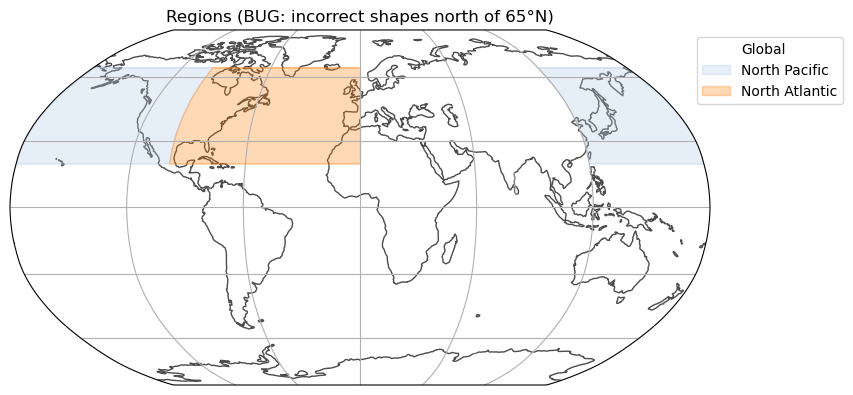

In [17]:
regions = { # [minx, maxx, miny, maxy], using model longitude range (-280 to 80)
    "Global": [-280, 80, -90, 90],
    # # "Arctic": [-280, 80, 65, 90],
    # # "Southern Ocean": [-280, 80, -82, -63],
    # # "ACC": [-280, 80, -63, -45],
    # # "Southern Pacific": [-210, -70, -45, -20],
    # # "Tropical Pacific": [-240, -100, -20, 20],
    "North Pacific": [-240, -100, 20, 65],
    # # "South Atlantic": [-60, 20, -45, -20],
    # # "Tropical Atlantic": [-70, 20, -20, 20],
    "North Atlantic": [-100, 0, 20, 65],
    # # "Indian": [30, 120, -45, 20],
    # "Aegean Sea": [18, 27.5, 34, 44],
    # "Black Sea": [27.5, 43, 40.5, 48],
    # "Baltic Sea": [13, 30, 53, 58],
    # "Mediterranean Sea": [0, 35, 31, 41],
    # "Red Sea": [33, 44, 12, 29],
    # "Persian Gulf": [47, 56, 24, 31],
    # "White Sea": [31, 41, 63, 68],
}
regions = {k: dict(zip(["minx", "maxx", "miny", "maxy"], v)) for k, v in regions.items()}  # convert to dicts

for r, d in regions.items():
    for k, x in d.items():
        if k in ["minx", "maxx"] and x != max(-280, min(x, 80)):
            raise ValueError(f"{r} {k} = {x} is outside the range -280 to 80")

fig = plt.figure(figsize=(10, 4))

colors = mpl.color_sequences['tab20']
try:  # set Global color to white 
    colors[list(regions.keys()).index("Global")] = (1, 1, 1)
except ValueError:
    pass

ax = plt.axes(position=[0.05,0.05,0.7,0.9], projection=ccrs.Robinson())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=False)

legend_elements = []
for i, (region, limits) in enumerate(regions.items()):
    ax.add_geometries([geometry.box(**limits)], crs=ccrs.PlateCarree(), color=colors[i], alpha=0.3)
    legend_elements.append(Patch(color=colors[i], alpha=0.3, label=region))

ax.legend(handles=legend_elements, bbox_to_anchor=(1.2, 1.00))
plt.title("Regions (BUG: incorrect shapes north of 65°N)")

### Timeseries

Global
North Pacific
North Atlantic


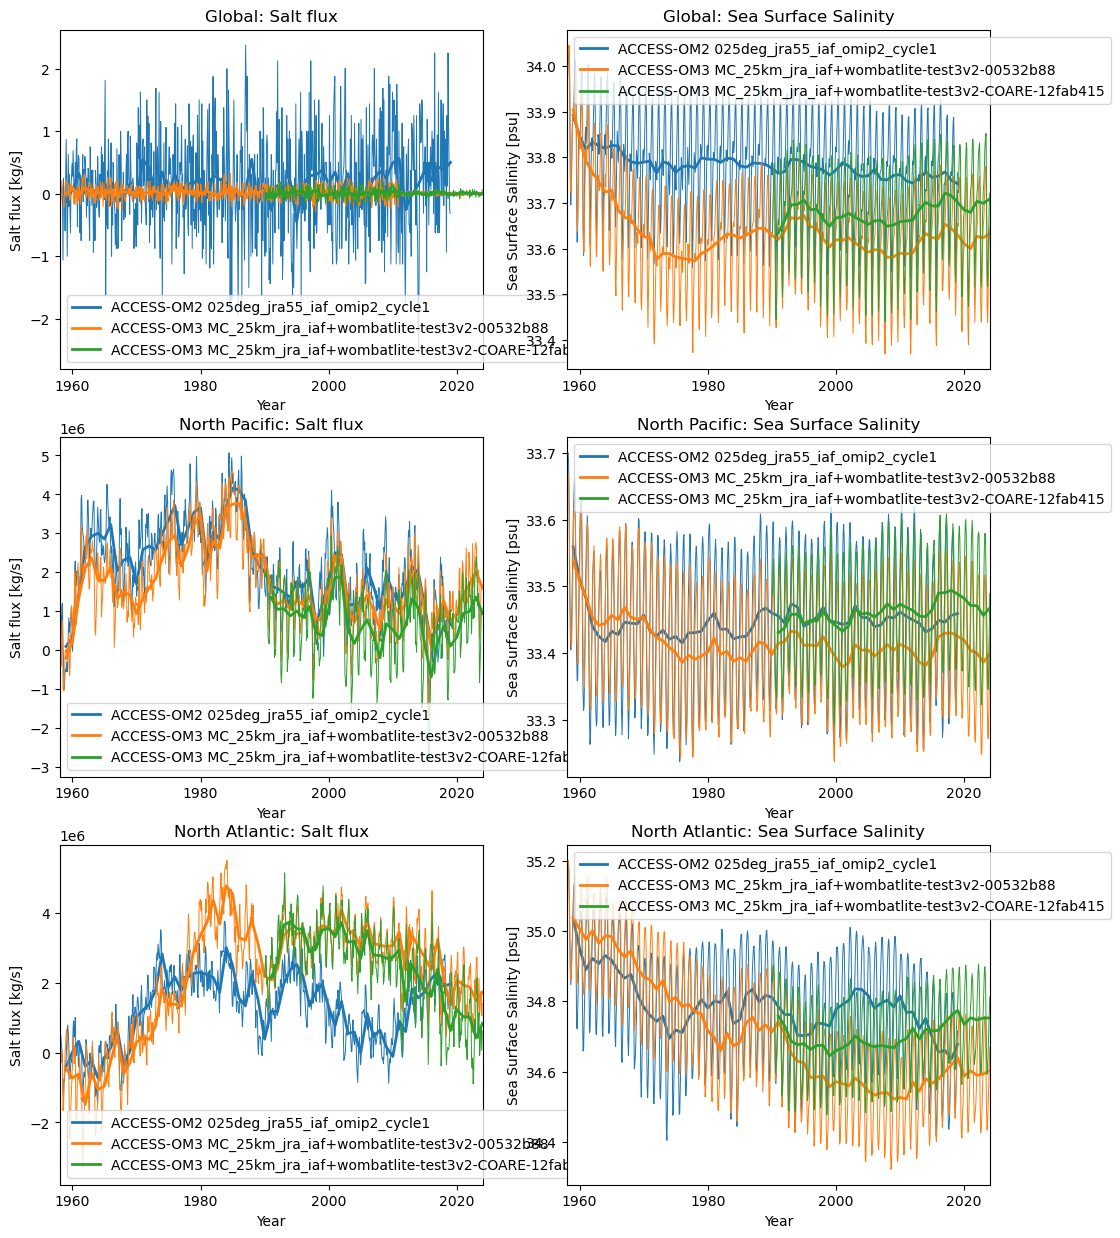

In [18]:
fig, axes = plt.subplots(nrows=len(regions), ncols=2, figsize=(12, 5*len(regions)))
for i, (region, bounds) in enumerate(regions.items()):
    print(region)
    minx, maxx, miny, maxy = bounds.values()

    try:
        ax1 = axes[i, 0]  # left column: restoring
    except IndexError:
        ax1 = axes[0]
    for expt, data in om2vars['sfc_salt_flux_restore_int'].items():
        d = ( data
            .sel(xt_ocean=slice(minx, maxx), yt_ocean=slice(miny, maxy))
            .sum(['xt_ocean', 'yt_ocean'], keep_attrs=True)
            .load()
            )
        p = d.plot(ax=ax1, linewidth=.7)
        d.resample(time='1YE').mean('time').plot(
                    ax=ax1,
                    linewidth=2,
                    color=p[-1].get_color(),
                    label=f"ACCESS-OM2 {expt}"
                )
    for expt, data in om3vars['salt_flux_added_int'].items():
        d = ( data
            .sel(xh=slice(minx, maxx), yh=slice(miny, maxy))
            .sum(['xh', 'yh'], keep_attrs=True)
            .load()
            )
        p = d.plot(ax=ax1, linewidth=.7)
        d.resample(time='1YE').mean('time').plot(
                    ax=ax1,
                    linewidth=2,
                    color=p[-1].get_color(),
                    label=f"ACCESS-OM3 {expt}"
                )
    ax1.set_ylabel("Salt flux [kg/s]")
    ax1.set_title(f"{region}: Salt flux")
    ax1.set_xlabel("Year")
    ax1.autoscale(enable=True, axis='x', tight=True)
    ax1.legend()

    try:
        ax1 = axes[i, 1]  # right column: SST
    except IndexError:
        ax1 = axes[1]
    for expt, data in om2vars['surface_salt'].items():
        d = ( data
            # .sel(xt_ocean=slice(minx, maxx)).mean('xt_ocean', keep_attrs=True)
            # .sel(yt_ocean=slice(miny, maxy)).mean('yt_ocean', keep_attrs=True)
            .sel(xt_ocean=slice(minx, maxx), yt_ocean=slice(miny, maxy))
            .mean(['xt_ocean', 'yt_ocean'], keep_attrs=True)  # BUG: not area-weighted
            .load()
            )
        p = d.plot(ax=ax1, linewidth=.7)
        d.resample(time='1YE').mean('time').plot(
                    ax=ax1,
                    linewidth=2,
                    color=p[-1].get_color(),
                    label=f"ACCESS-OM2 {expt}"
                )
    for expt, data in om3vars['sos'].items():
        d = ( data
            # .sel(xh=slice(minx, maxx)).mean('xh', keep_attrs=True)
            # .sel(yh=slice(miny, maxy)).mean('yh', keep_attrs=True)
            .sel(xh=slice(minx, maxx), yh=slice(miny, maxy))
            .mean(['xh', 'yh'], keep_attrs=True)  # BUG: not area-weighted
            .load()
            )
        p = d.plot(ax=ax1, linewidth=.7)
        d.resample(time='1YE').mean('time').plot(
                    ax=ax1,
                    linewidth=2,
                    color=p[-1].get_color(),
                    label=f"ACCESS-OM3 {expt}"
                )
    ax1.set_ylabel(f"{d.attrs['long_name']} [{d.attrs['units']}]")
    ax1.set_title(f"{region}: {d.attrs['long_name']}")
    ax1.set_xlabel("Year")
    ax1.autoscale(enable=True, axis='x', tight=True)
    ax1.legend()


### Maps

Global
North Pacific
North Atlantic
CPU times: user 8.33 s, sys: 599 ms, total: 8.93 s
Wall time: 11.5 s


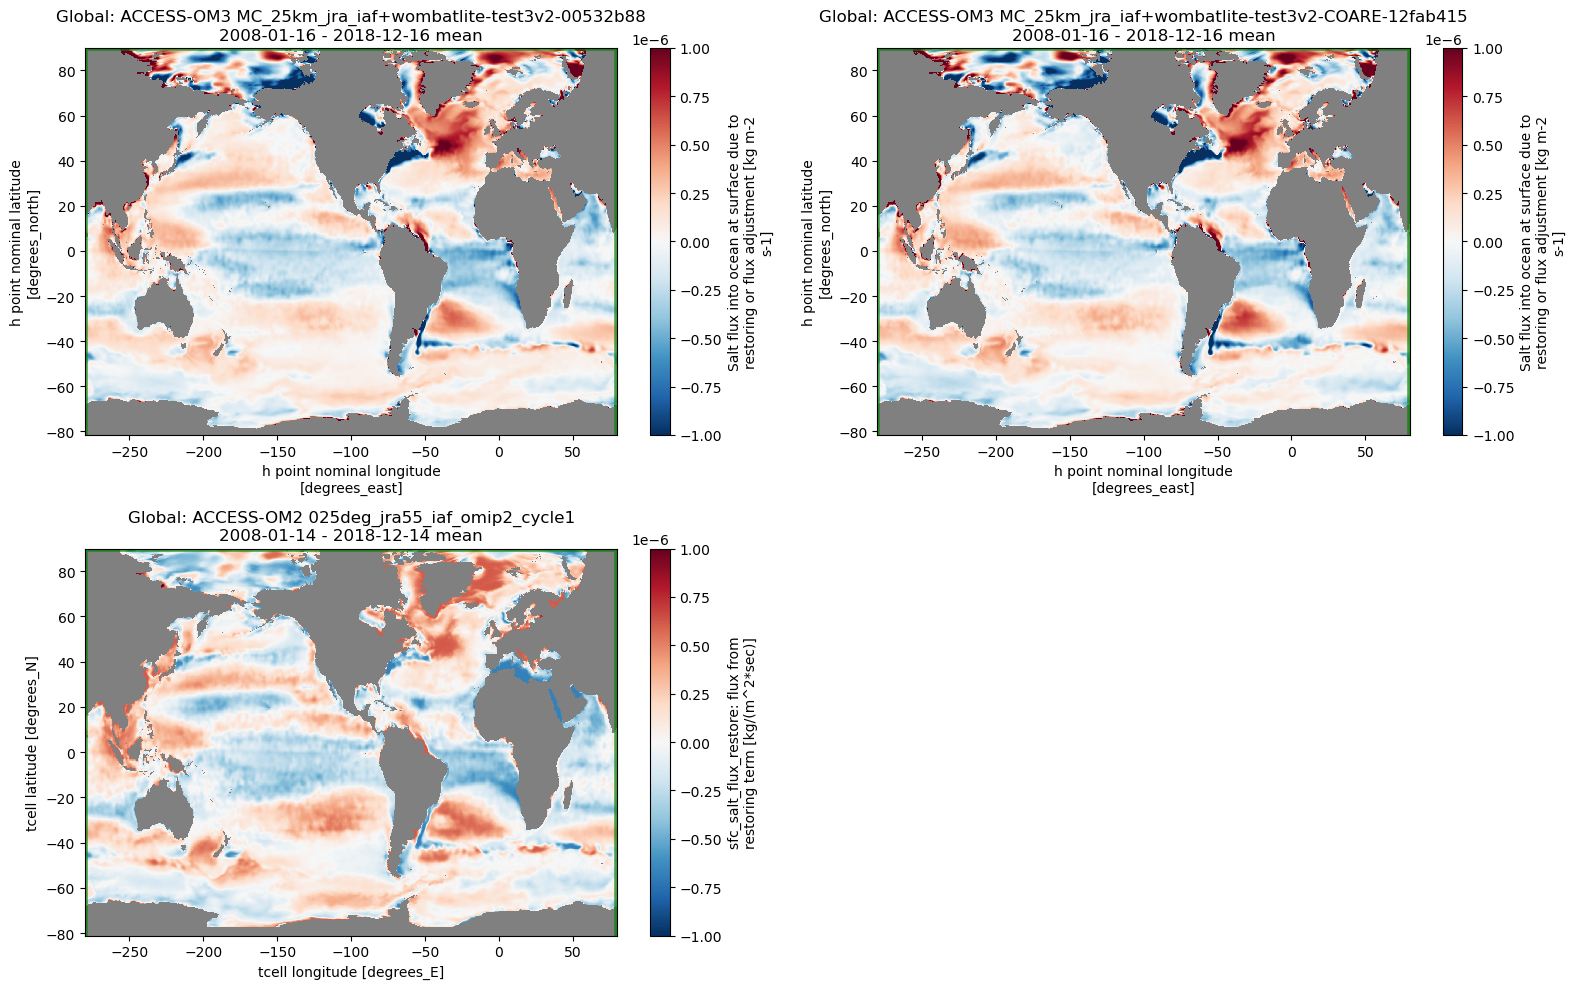

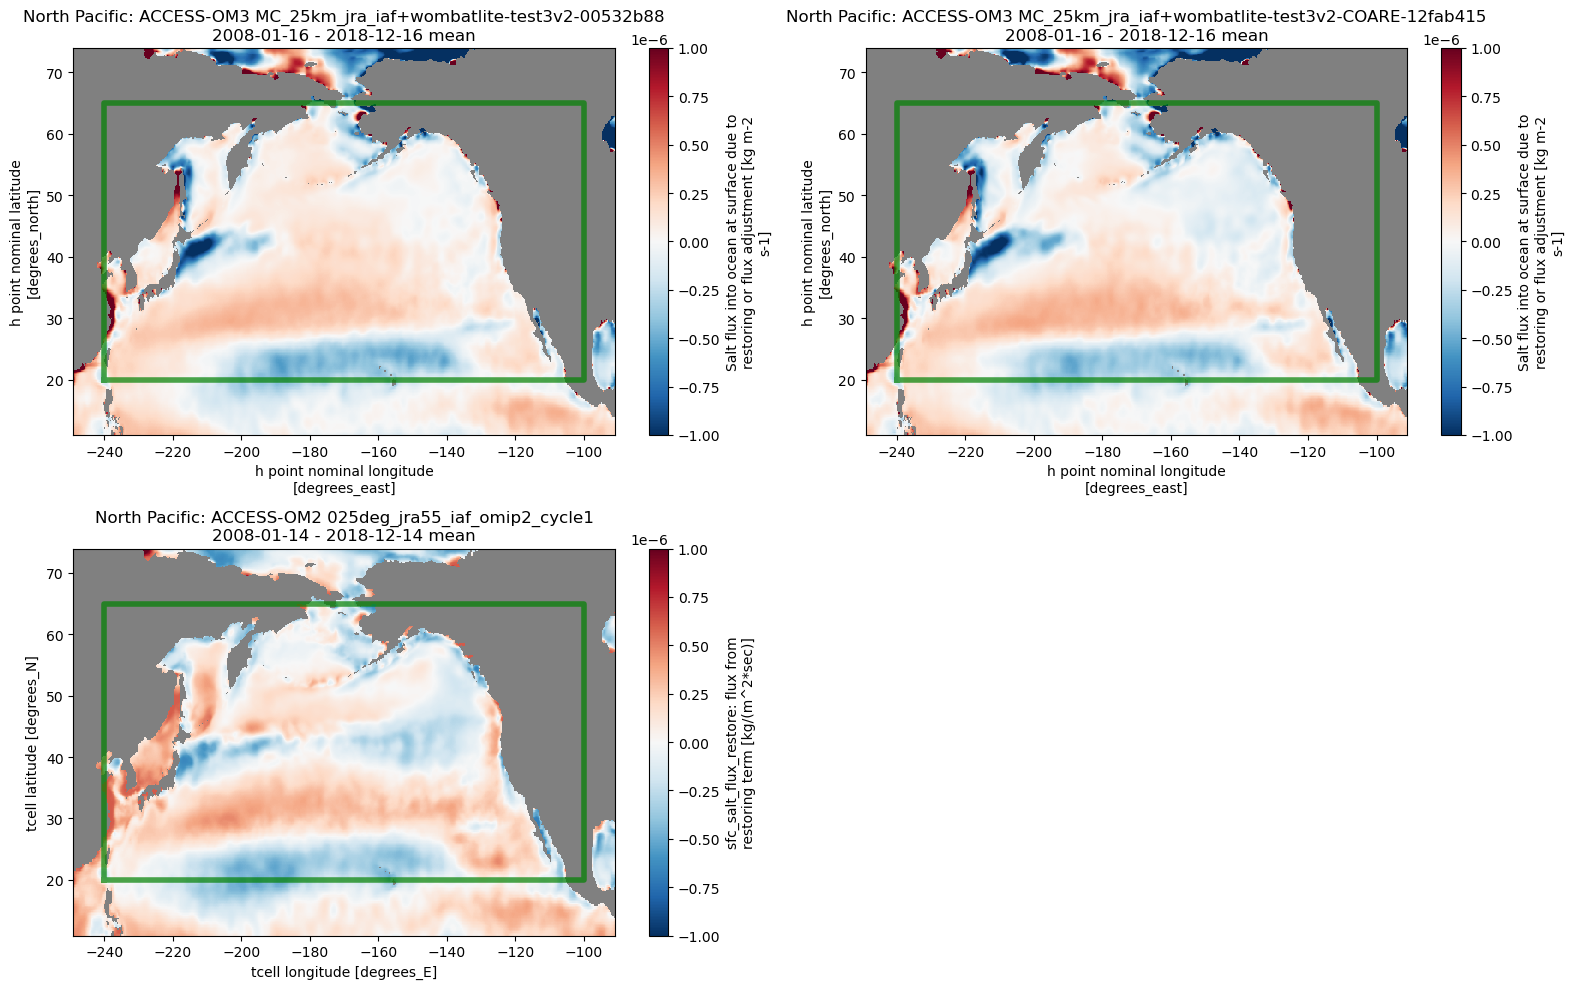

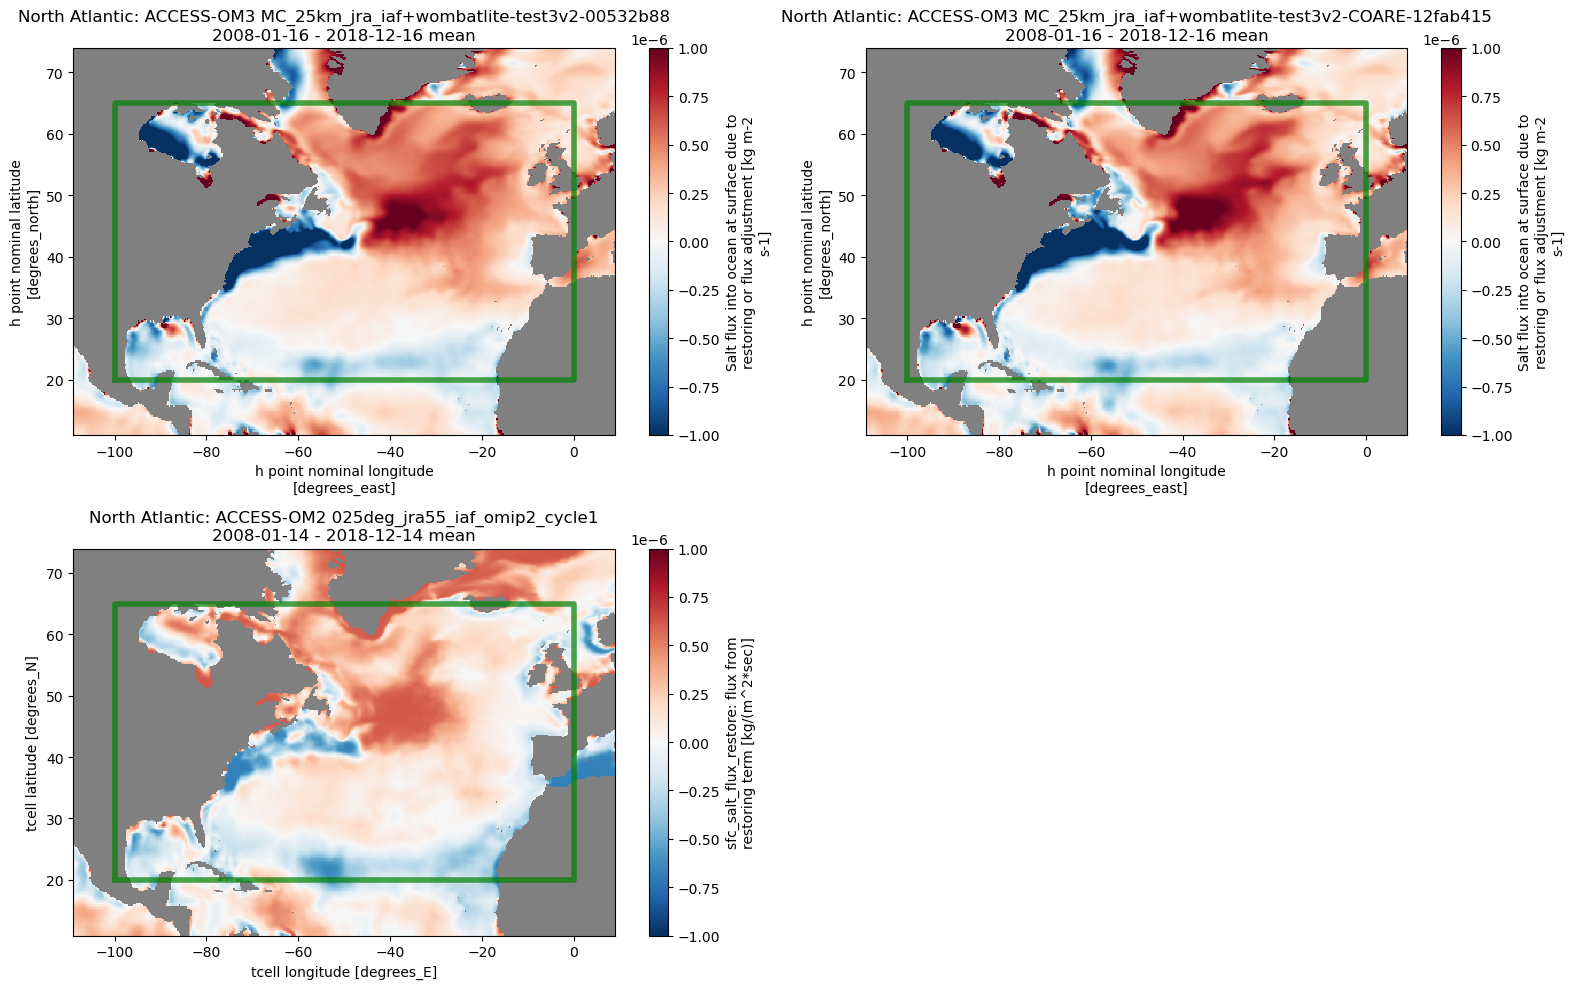

In [19]:
%%time
margin = 9
vmax = 1e-6
om3variable = "salt_flux_added"
om2variable = "sfc_salt_flux_restore"
for region, bounds in regions.items():
    print(region)
    minx, maxx, miny, maxy = bounds.values()
    xslice = slice(minx-margin, maxx+margin)
    yslice = slice(miny-margin, maxy+margin)
    npanels = len(om3vars[om3variable]) + len(om2vars[om2variable])
    nrows = (npanels+1)//2
    fig, axs = plt.subplots(nrows, 2,
                            figsize=(16, 5*nrows))
                            # figsize=(9, 3*nrows))

    # ACCESS-OM3
    for i, (expt, d) in enumerate(om3vars[om3variable].items(), start=1):
        plt.subplot(nrows, 2, i).set_facecolor('gray')  # gray land points
        data = d.sel(xh=xslice, yh=yslice, time=timeslice)
        p1 = data.mean('time').plot(vmax=vmax, add_colorbar=False)
        plt.plot([minx, maxx, maxx, minx, minx],
                 [miny, miny, maxy, maxy, miny],
                 color='green', linewidth=4, alpha=0.7)
        plt.title(f'{region}: ACCESS-OM3 {expt}\n{data.time.values[0].strftime("%Y-%m-%d")} - {data.time.values[-1].strftime("%Y-%m-%d")} mean')
        cbar1 = plt.colorbar(p1, orientation="vertical")
        cbar1.set_label('\n'.join(textwrap.wrap(
            f"{d.attrs['long_name']} [{d.attrs['units']}]",
            width=40)))

    # ACCESS-OM2
    for i, (expt, d) in enumerate(om2vars[om2variable].items(), start=i+1):
        plt.subplot(nrows, 2, i).set_facecolor('gray')  # gray land points
        data = d.sel(xt_ocean=xslice, yt_ocean=yslice, time=timeslice)
        p1 = data.mean('time').plot(vmax=vmax, add_colorbar=False)
        plt.plot([minx, maxx, maxx, minx, minx],
                 [miny, miny, maxy, maxy, miny],
                 color='green', linewidth=4, alpha=0.7)
        plt.title(f'{region}: ACCESS-OM2 {expt}\n{data.time.values[0].strftime("%Y-%m-%d")} - {data.time.values[-1].strftime("%Y-%m-%d")} mean')
        cbar1 = plt.colorbar(p1, orientation="vertical")
        cbar1.set_label('\n'.join(textwrap.wrap(
            f"{d.attrs['long_name']} [{d.attrs['units']}]",
            width=40)))

    try:  # drop empty subfigs (if any)
        fig.delaxes(axs.flatten()[i])
    except IndexError:
        pass

    plt.tight_layout()

## Compare salt restoring (expressed as equivalent freshwater flux) to E-P and sea ice fluxes

- salt_flux_added:long_name = "Salt flux into ocean at surface due to restoring or flux adjustment" ;
- salt_flux_added:units = "kg m-2 s-1" ;        <--- **salt** mass flux, not water mass mass
  
- wfo:long_name = "Water Flux Into Sea Water" ;
- wfo:units = "kg m-2 s-1" ;

- evs:long_name = "Water Evaporation Flux Where Ice Free Ocean over Sea" ;
- evs:units = "kg m-2 s-1" ;

- precip:long_name = "Liquid + frozen precipitation into ocean" ;
- precip:units = "kg m-2 s-1" ;

- ficeberg:long_name = "Water Flux into Seawater from Icebergs" ;
- ficeberg:units = "kg m-2 s-1" ;


#### Note the units.
- 1 kg m-2 s-1 = 1 mm/s = 86400 mm/day for water
- Convert from salt mass flux to equivalent fresh water mass flux by dividing by salinity (in units of kg salt/kg seawater water, ie PSU/1000) and changing sign

In [20]:
# add some more variables to om3vars, but only for expt
expt = om3exptname
varnames = [
                "salt_flux_added",
                "sos",
                "wfo",
                "evs",
                "precip",
                "ficeberg",
            ]

for vname in varnames:
    if vname not in om3vars or len(om3vars[vname]) == 0:
        print('adding ', vname)
        om3vars[vname] = dict()
        om3vars[vname][expt] = om3datastores[expt].search(variable=vname).to_dask(
                xarray_open_kwargs = dict(
                    # chunks={"xh": -1, "yh": -1},
                    chunks={"time": -1},
                    decode_timedelta=True,
                    use_cftime=True
                )
            )[vname]
        if IAF:
            om3vars[vname][expt] = om3vars[vname][expt].convert_calendar("proleptic_gregorian", use_cftime=True)

adding  wfo
adding  evs
adding  precip
adding  ficeberg


In [21]:
# add salt_flux_added_as_water to om3vars, but only for expt

factor = om3vars['sos'][expt]/1000  # converts sos from ppt
factor['time'] = om3vars['salt_flux_added'][expt].time  # deal with offset time
salt_flux_added_as_water = -om3vars['salt_flux_added'][expt] / factor  # express salt flux as equivalent freshwater flux
salt_flux_added_as_water.attrs = om3vars['salt_flux_added'][expt].attrs
salt_flux_added_as_water.attrs['long_name'] = salt_flux_added_as_water.attrs['long_name'] + ", expressed as equivalent water flux"

om3vars['salt_flux_added_as_water'] = dict()
om3vars['salt_flux_added_as_water'][expt] = salt_flux_added_as_water

salt_flux_added_as_water
wfo
evs
precip
ficeberg
CPU times: user 21.8 s, sys: 3.44 s, total: 25.3 s
Wall time: 1min 17s


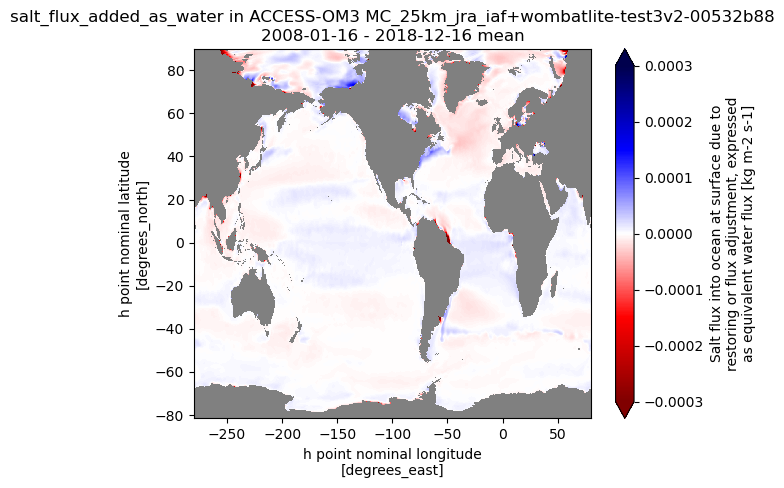

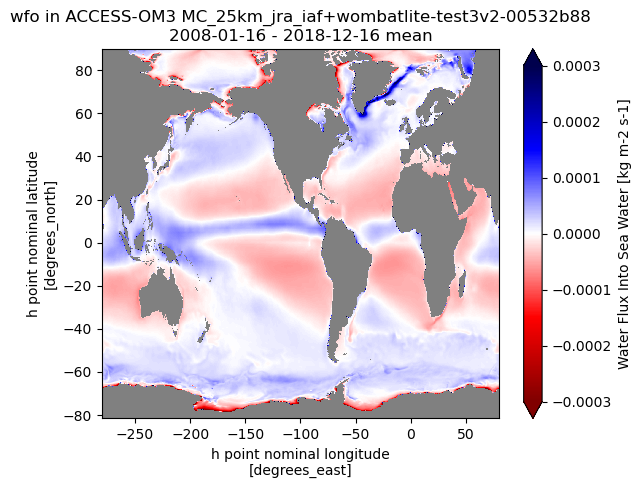

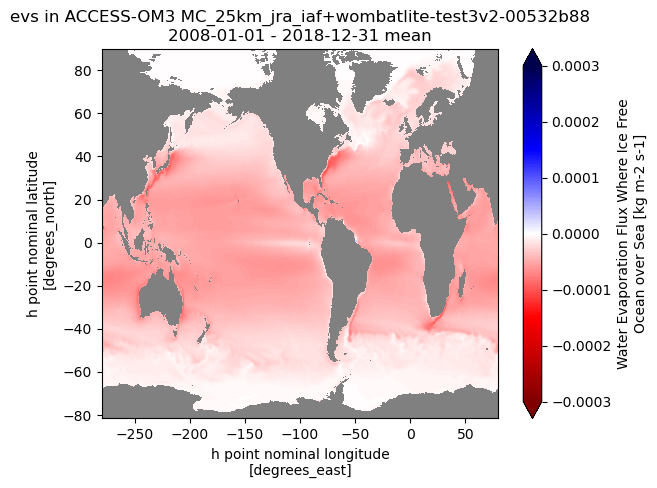

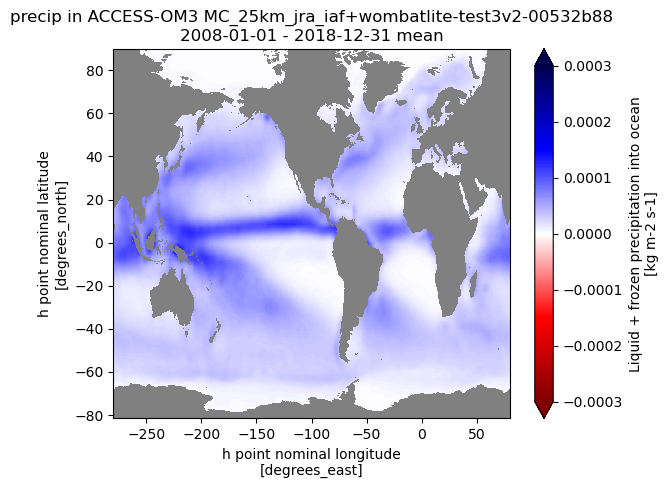

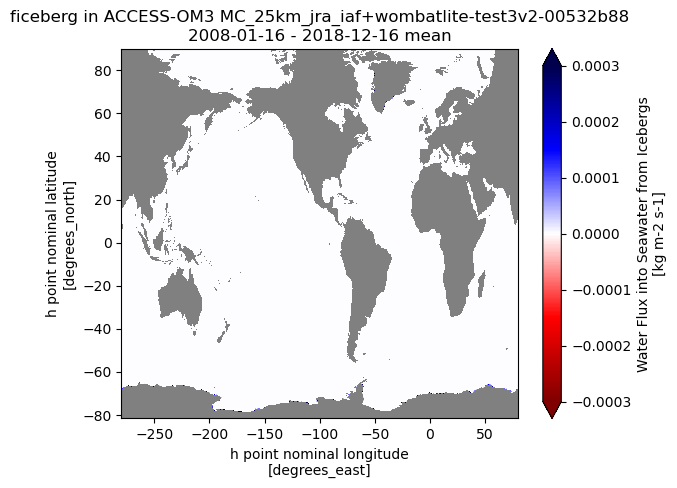

In [22]:
%%time
vmax = 3e-4
varnames = [
                "salt_flux_added_as_water",
                "wfo",
                "evs",
                "precip",
                "ficeberg",
            ]
for vname in varnames:
    print(vname)
    plt.figure()
    plt.subplot(1, 1, 1).set_facecolor('gray')  # gray land points
    data = om3vars[vname][expt].sel(time=timeslice)
    p1 = data.mean('time').load().plot(vmax=vmax,
                                       vmin=-vmax,
                                       cmap='seismic_r',
                                       add_colorbar=False)
    plt.title(f'{vname} in ACCESS-OM3 {expt}\n{data.time.values[0].strftime("%Y-%m-%d")} - {data.time.values[-1].strftime("%Y-%m-%d")} mean')
    cbar1 = plt.colorbar(p1, orientation="vertical", extend="both")
    cbar1.set_label('\n'.join(textwrap.wrap(
        f"{data.attrs['long_name']} [{data.attrs['units']}]",
        width=40)))

## Plots of SSS minus SSS monthly climatology used for restoring for OM3 and OM2

Convert OM3 sos from practical to absolute salinity, as [that's how restoring is calculated](https://github.com/ACCESS-NRI/access-om3-configs/issues/845#issuecomment-3430261033)

In [23]:
# path is a workaround - see https://forum.access-hive.org.au/t/issues-in-loading-ht-in-latest-conds-envs/6278
path = om3datastores[om3exptname].search(variable=["geolat", "geolon"], filename="access-om3.mom6.static.nc").df.loc[0, 'path']
geolon = om3datastores[om3exptname].search(variable="geolon", path=path, filename="access-om3.mom6.static.nc").to_dask().geolon
geolat = om3datastores[om3exptname].search(variable="geolat", path=path, filename="access-om3.mom6.static.nc").to_dask().geolat

# https://teos-10.github.io/GSW-Python/_modules/gsw/_wrapped_ufuncs.html#SA_from_SP
om3_sss = gsw.conversions.SA_from_SP(om3vars['sos'][om3exptname], 0, geolon, geolat)
om3_sss.attrs['long_name'] = 'Sea Surface Absolute Salinity'
om3_sss.attrs['units'] = 'g kg-1'

In [24]:
om2_sss = om2vars['surface_salt'][om2exptname]

In [25]:
# specific SSS restoring file used for each run (this is absolute salinity for OM3)
sss_restore_paths = {
    'MC_25km_jra_iaf+wombatlite-test3v2-00532b88': '/g/data/vk83/configurations/inputs/access-om3/mom/surface_salt_restoring/global.25km/2025.10.24/salt_sfc_restore.nc',
    'MC_25km_jra_iaf-1.0-beta-5165c0f8':           '/g/data/vk83/configurations/inputs/access-om3/mom/surface_salt_restoring/global.25km/2025.10.24/salt_sfc_restore.nc',
    '025deg_jra55_iaf_omip2_cycle1':               '/g/data/ik11/inputs/access-om2/input_20200530/mom_025deg/salt_sfc_restore.nc',  # https://github.com/rmholmes/025deg_jra55_iaf/blob/5235afc91185c3d6b745e90aa5174f4173e126aa/config.yaml#L41
}
om3_sss_restore_path = sss_restore_paths[om3exptname]
om2_sss_restore_path = sss_restore_paths[om2exptname]

om3_sss_WOA = xr.open_dataset(om3_sss_restore_path)['asalt'].rename({'lon': 'xh', 'lat': 'yh'})  # absolute salinity

om2_sss_WOA = xr.open_dataset(om2_sss_restore_path, decode_times=False, use_cftime=False).rename({'lon': 'xt_ocean', 'lat': 'yt_ocean'})
# nasty kludges to fix up time axis
om2_sss_WOA['time'] = om2_sss_WOA['time']*30  # roughly convert months to days
om2_sss_WOA['time'].attrs.pop('calendar_type', None)
om2_sss_WOA['time'].attrs['calendar'] = 'gregorian'
om2_sss_WOA['time'].attrs['units'] = 'days since 1900-01-01 00:00:00'  # to suit gregorian
om2_sss_WOA = xr.decode_cf(om2_sss_WOA)['salt']
# fix grid mismatch in tripolar region
om2_sss_WOA['xt_ocean'] = om2_sss['xt_ocean']
om2_sss_WOA['yt_ocean'] = om2_sss['yt_ocean']

In [32]:
%%time
om3_sss_bias = (
        om3_sss.sel(time=timeslice).groupby('time.month').mean('time')
        - om3_sss_WOA.groupby('time.month').mean('time')
    ).load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 152.46 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 14.1 s, sys: 3.98 s, total: 18 s
Wall time: 37.4 s


In [33]:
%%time
om2_sss_bias = (
        om2_sss.sel(time=timeslice).groupby('time.month').mean('time')
        - om2_sss_WOA.groupby('time.month').mean('time')
    ).load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 72.77 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 9.1 s, sys: 1.43 s, total: 10.5 s
Wall time: 24 s


Text(0.5, 1.0, 'ACCESS-OM3 SSS minus WOA restoring\nMC_25km_jra_iaf+wombatlite-test3v2-00532b88 2008-01-01 - 2018-12-31 mean')

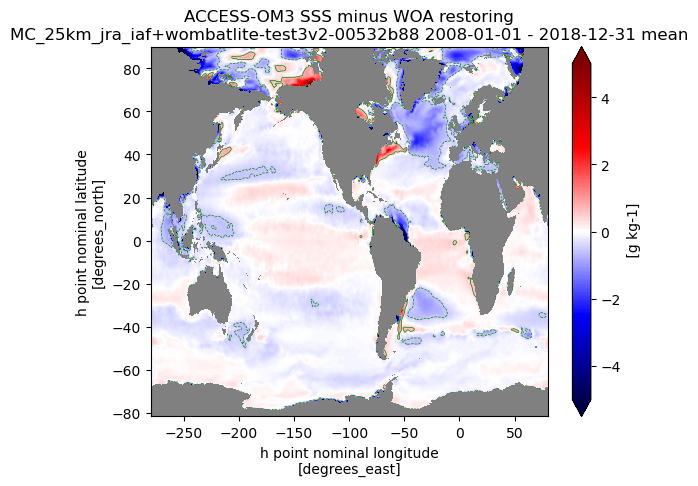

In [34]:
vmax = 5
MAX_DELTA_SRESTORE = 0.5  # psu

plt.figure()
plt.subplot(1, 1, 1).set_facecolor('gray')  # gray land points
om3_sss_bias.mean('month').plot(vmax=vmax, vmin=-vmax, cmap='seismic')
om3_sss_bias.mean('month').plot.contour(levels = [-MAX_DELTA_SRESTORE, MAX_DELTA_SRESTORE], colors='g', linewidths=0.5)
plt.title(f"")
plt.title(f'ACCESS-OM3 SSS minus WOA restoring\n{om3exptname} {timeslice.start.strftime("%Y-%m-%d")} - {timeslice.stop.strftime("%Y-%m-%d")} mean')

Text(0.5, 1.0, 'ACCESS-OM2 SSS minus WOA restoring\n025deg_jra55_iaf_omip2_cycle1 2008-01-01 - 2018-12-31 mean')

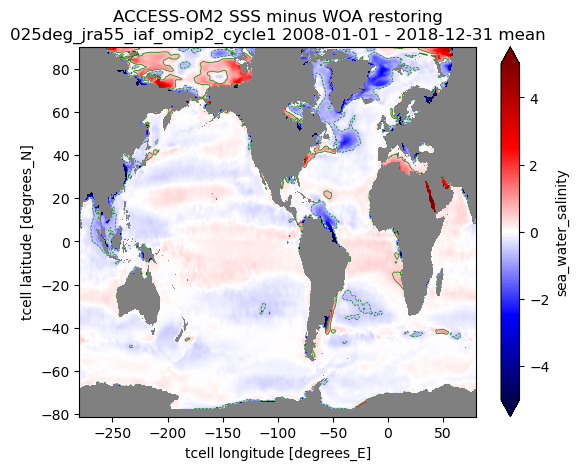

In [35]:
plt.figure()
plt.subplot(1, 1, 1).set_facecolor('gray')  # gray land points
om2_sss_bias.mean('month').plot(vmax=vmax, vmin=-vmax, cmap='seismic')
om2_sss_bias.mean('month').plot.contour(levels = [-MAX_DELTA_SRESTORE, MAX_DELTA_SRESTORE], colors='g', linewidths=0.5)
plt.title(f'ACCESS-OM2 SSS minus WOA restoring\n{om2exptname} {timeslice.start.strftime("%Y-%m-%d")} - {timeslice.stop.strftime("%Y-%m-%d")} mean')

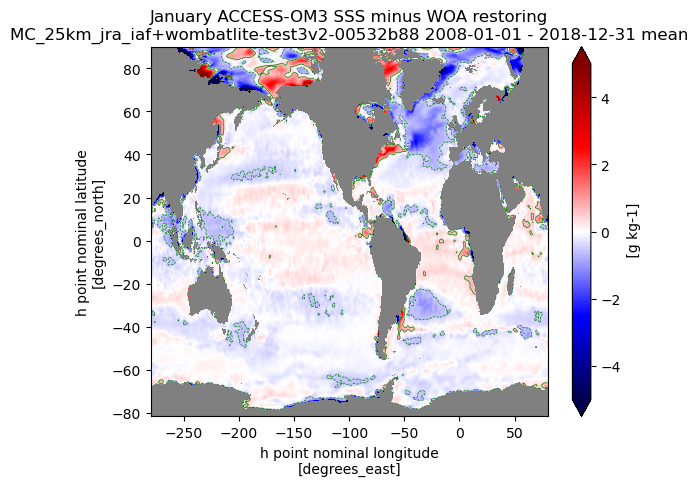

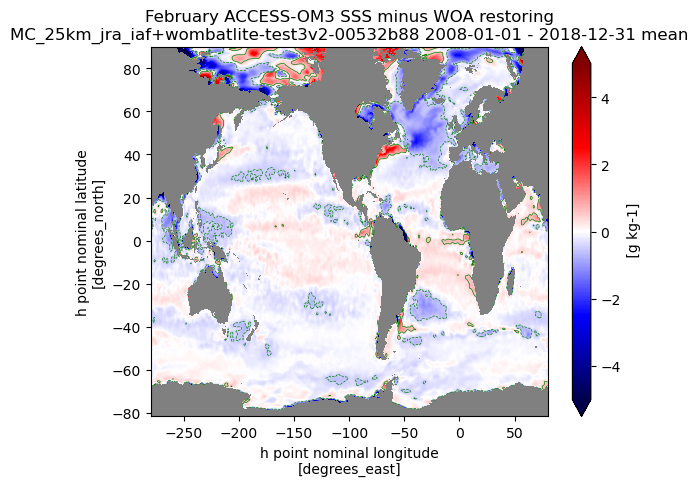

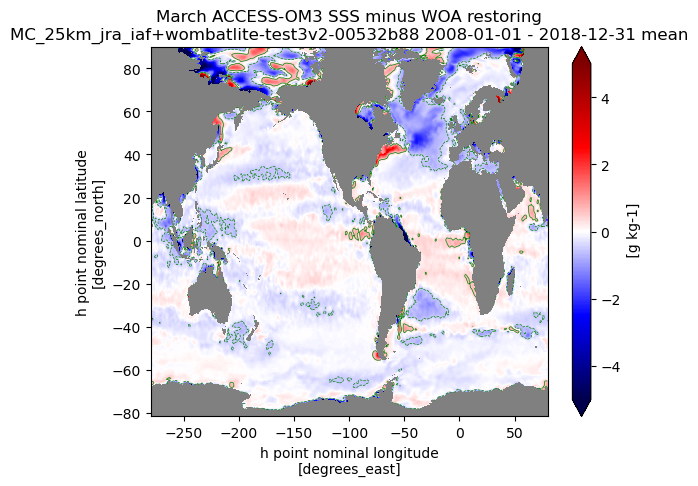

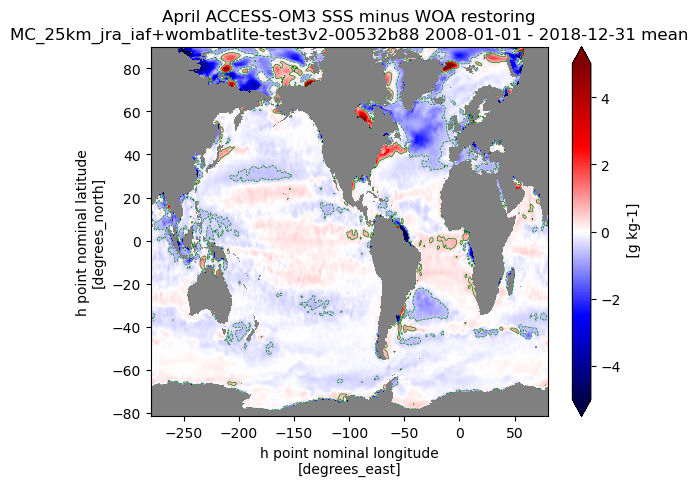

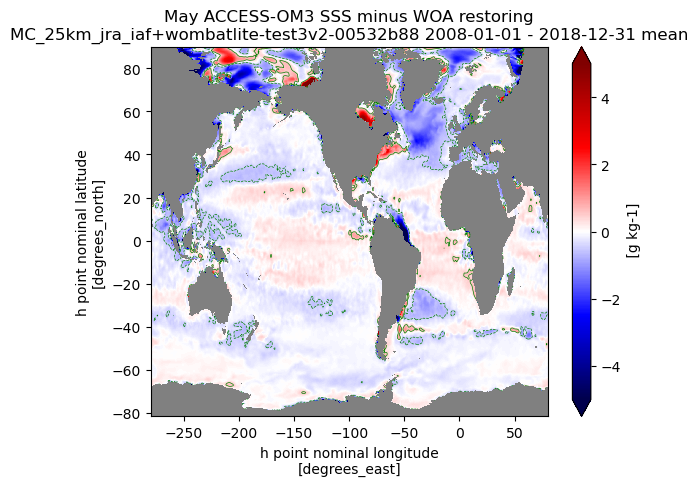

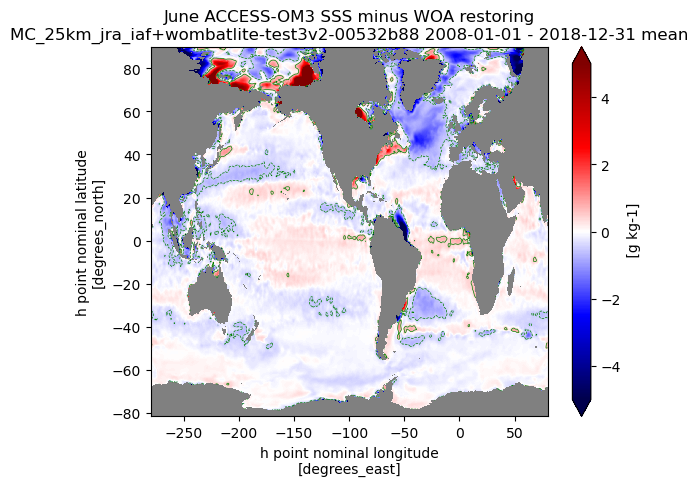

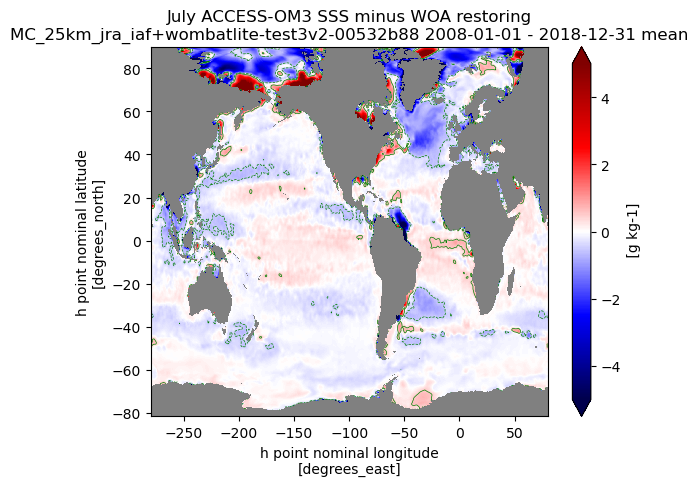

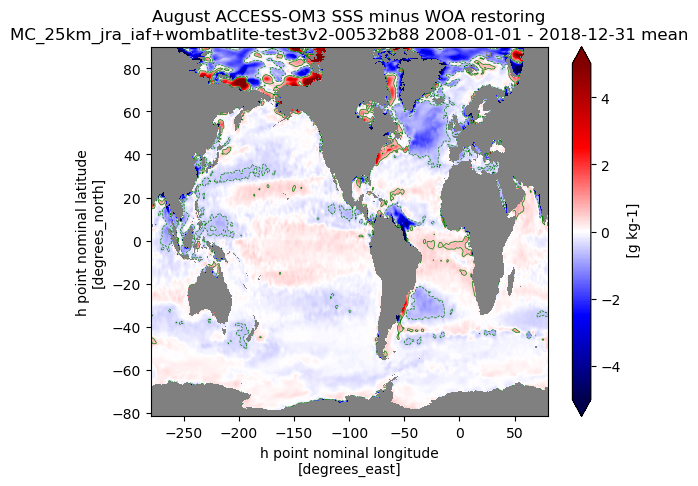

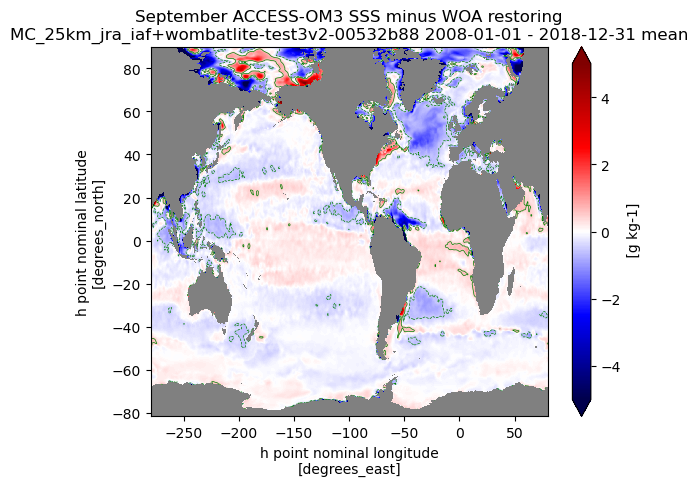

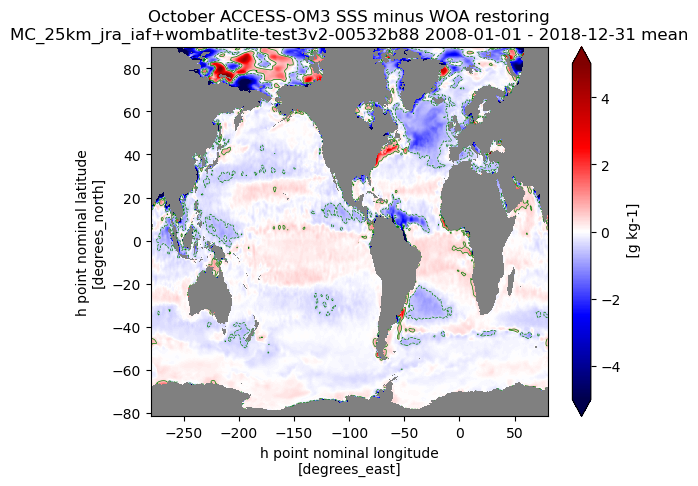

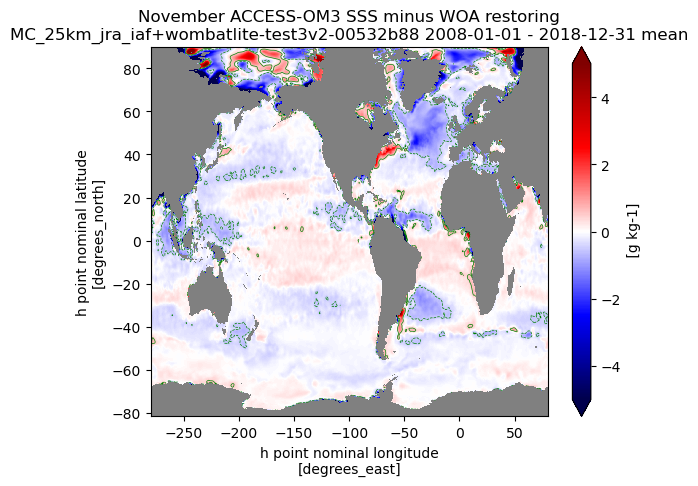

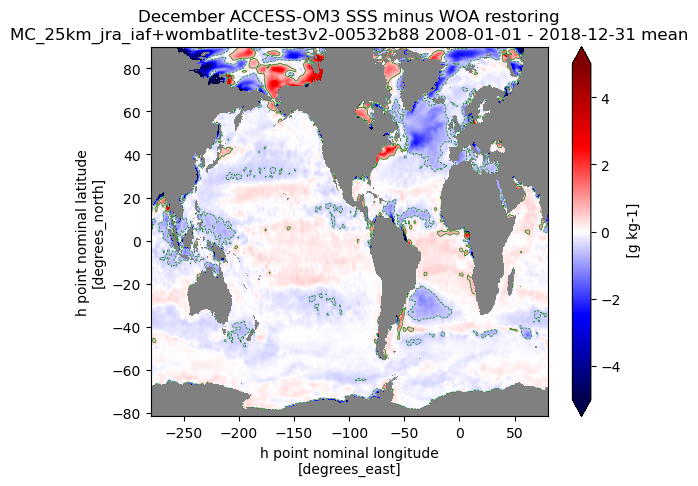

In [36]:
for m in range(12):
    plt.figure()
    plt.subplot(1, 1, 1).set_facecolor('gray')  # gray land points
    om3_sss_bias.sel(month=m+1).plot(vmax=vmax, vmin=-vmax, cmap='seismic')
    om3_sss_bias.sel(month=m+1).plot.contour(levels = [-MAX_DELTA_SRESTORE, MAX_DELTA_SRESTORE], colors='g', linewidths=0.5)
    plt.title(f'{calendar.month_name[m+1]} ACCESS-OM3 SSS minus WOA restoring\n{om3exptname} {timeslice.start.strftime("%Y-%m-%d")} - {timeslice.stop.strftime("%Y-%m-%d")} mean')

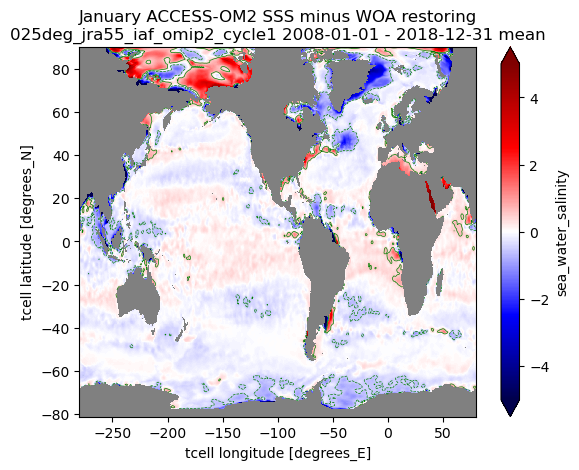

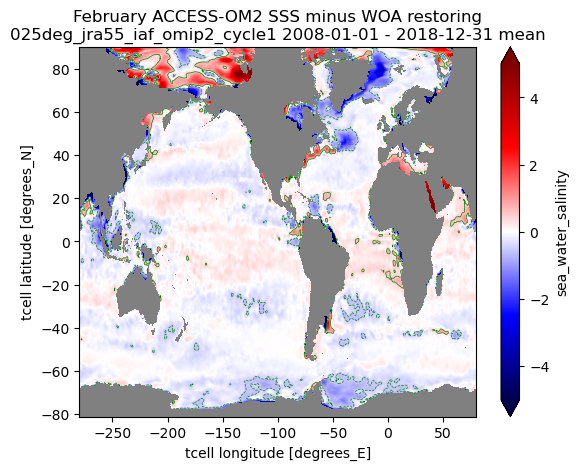

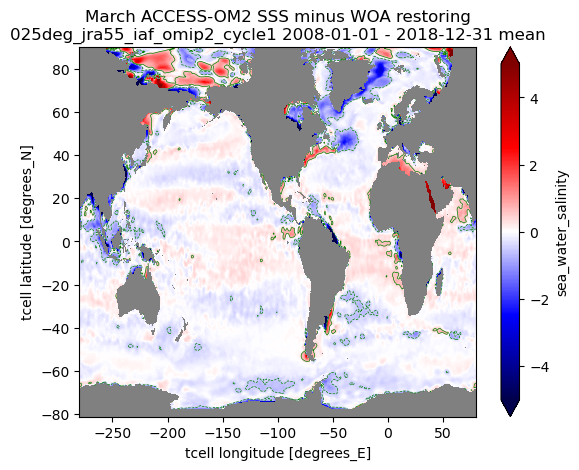

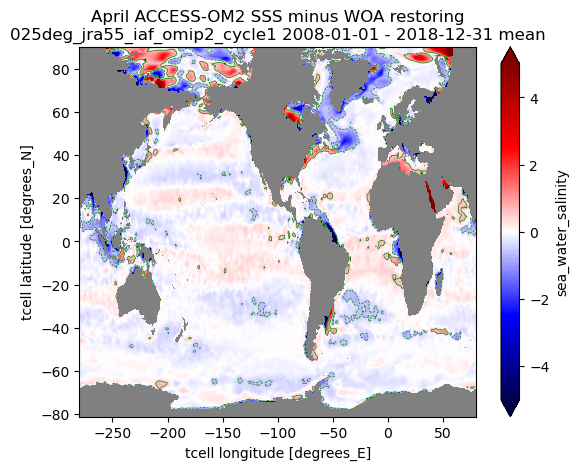

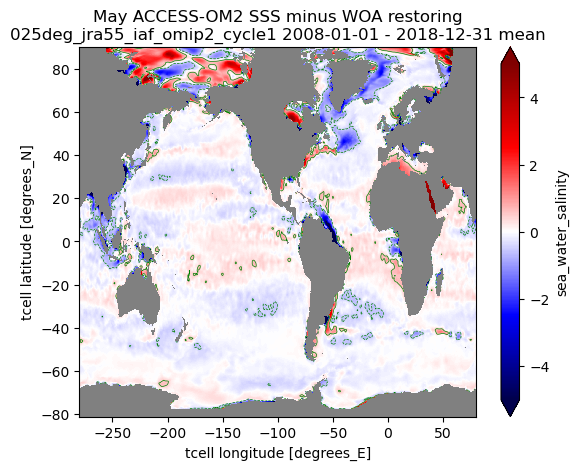

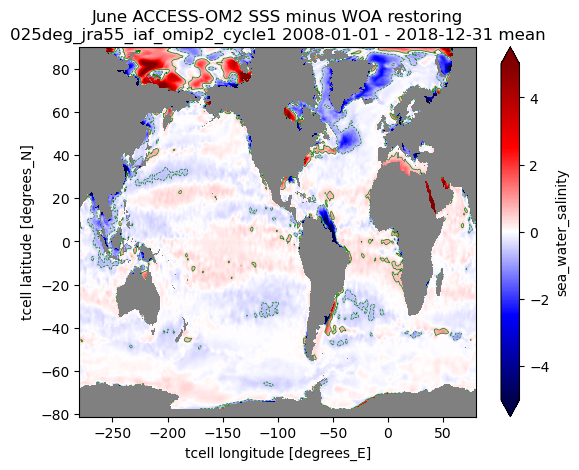

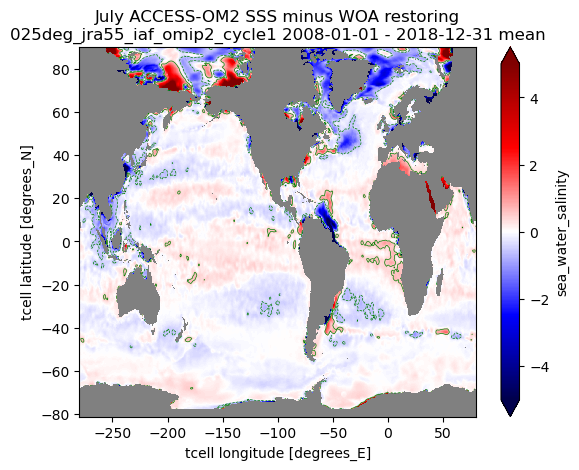

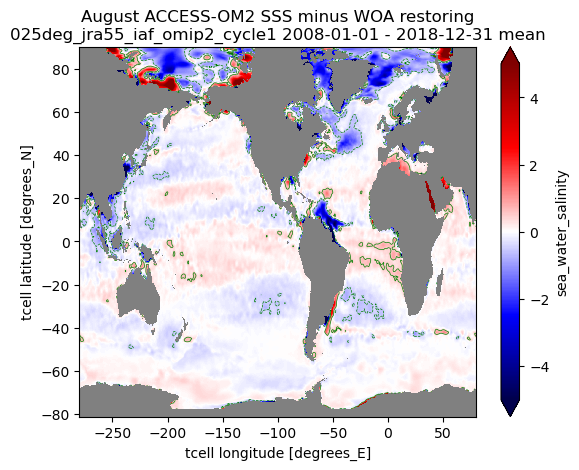

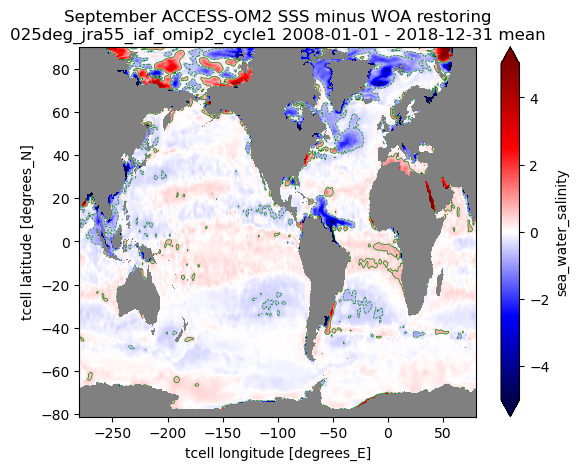

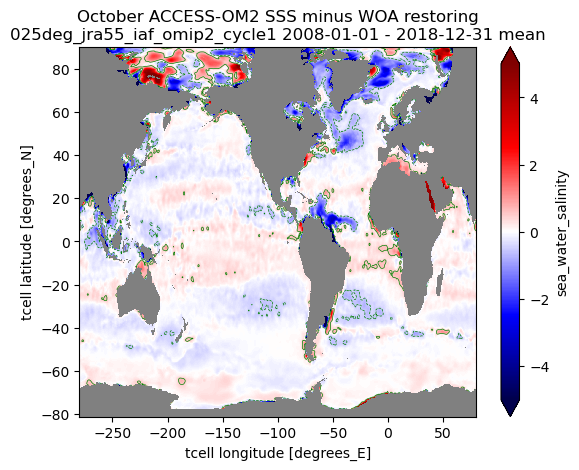

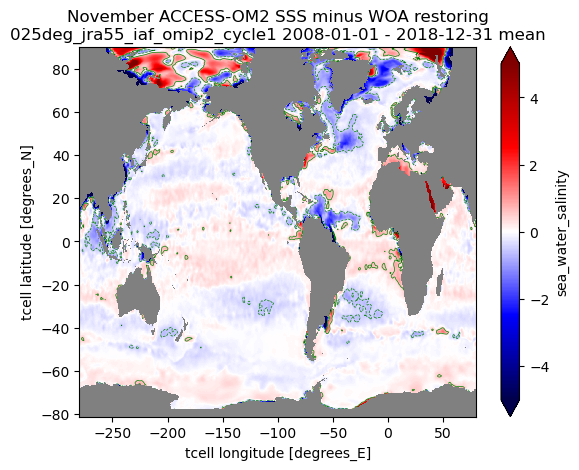

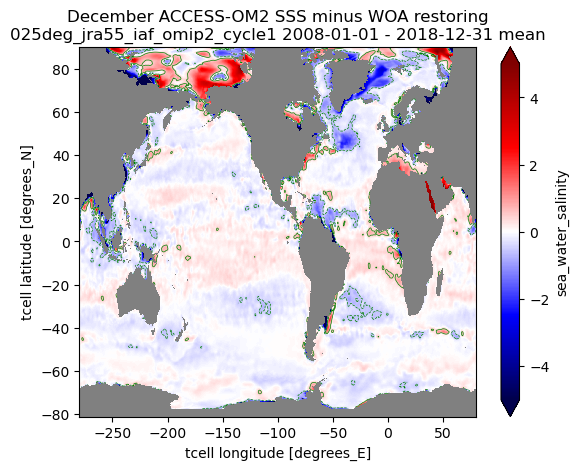

In [37]:
for m in range(12):
    plt.figure()
    plt.subplot(1, 1, 1).set_facecolor('gray')  # gray land points
    om2_sss_bias.sel(month=m+1).plot(vmax=vmax, vmin=-vmax, cmap='seismic')
    om2_sss_bias.sel(month=m+1).plot.contour(levels = [-MAX_DELTA_SRESTORE, MAX_DELTA_SRESTORE], colors='g', linewidths=0.5)
    plt.title(f'{calendar.month_name[m+1]} ACCESS-OM2 SSS minus WOA restoring\n{om2exptname} {timeslice.start.strftime("%Y-%m-%d")} - {timeslice.stop.strftime("%Y-%m-%d")} mean')